# Install and Import Dependencies

In [1]:
#!pip install prophet 

In [2]:
import warnings 
warnings.simplefilter('ignore')
import pandas as pd
import prophet
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller #Augmented Dickey-Fuller (ADF) Test, which is a statistical test designed to check for stationarity in a time series.
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import numpy as np

# 1. Read in Data and Process Dates

In [3]:
df = pd.read_csv('Profit.csv')
df.head()

,Time Date,Product,Store,Value
0,1012018,2667437,QLD_CW_ST0203,2926.000
1,2012018,2667437,QLD_CW_ST0203,2687.531
2,3012018,2667437,QLD_CW_ST0203,2793.000
3,4012018,2667437,QLD_CW_ST0203,2394.000
4,5012018,2667437,QLD_CW_ST0203,2660.000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time Date  1080 non-null   int64  
 1   Product    1080 non-null   int64  
 2   Store      1080 non-null   object 
 3   Value      1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


In [5]:
#Converts the Time Date value to a string, last 4 characters of the string, representing the year.
df['Year'] = df['Time Date'].apply(lambda x: str(x)[-4:]) 

In [6]:
df.head()

,Time Date,Product,Store,Value,Year
0,1012018,2667437,QLD_CW_ST0203,2926.000,2018
1,2012018,2667437,QLD_CW_ST0203,2687.531,2018
2,3012018,2667437,QLD_CW_ST0203,2793.000,2018
3,4012018,2667437,QLD_CW_ST0203,2394.000,2018
4,5012018,2667437,QLD_CW_ST0203,2660.000,2018


In [ ]:
df.tail()

In [7]:
df['Month'] = df['Time Date'].apply(lambda x: str(x)[-6:-4])

df['Day'] = df['Time Date'].apply(lambda x: str(x)[:-6])

In [8]:
df['Formated Date'] = pd.DatetimeIndex(df['Year']+'-'+df['Month']+'-'+df['Day'])
df.head()

,Time Date,Product,Store,Value,Year,Month,Day,Formated Date
0,1012018,2667437,QLD_CW_ST0203,2926.000,2018,01,1,2018-01-01
1,2012018,2667437,QLD_CW_ST0203,2687.531,2018,01,2,2018-01-02
2,3012018,2667437,QLD_CW_ST0203,2793.000,2018,01,3,2018-01-03
3,4012018,2667437,QLD_CW_ST0203,2394.000,2018,01,4,2018-01-04
4,5012018,2667437,QLD_CW_ST0203,2660.000,2018,01,5,2018-01-05


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Time Date      1080 non-null   int64         
 1   Product        1080 non-null   int64         
 2   Store          1080 non-null   object        
 3   Value          1080 non-null   float64       
 4   Year           1080 non-null   object        
 5   Month          1080 non-null   object        
 6   Day            1080 non-null   object        
 7   Formated Date  1080 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 67.6+ KB


In [10]:
df.Store.value_counts()

QLD_CW_ST0203    1080
Name: Store, dtype: int64

In [11]:
df.shape

(1080, 8)

In [ ]:
#df = df.loc[(df['Store']=='QLD_CW_ST0203') & (df['Product']==2667437)]

In [12]:
df.drop(['Time Date', 'Product', 'Store', 'Year', 'Month', 'Day'], axis=1, inplace=True)
df.columns = ['Value', 'Formated Date']

In [13]:
df.head()

,Value,Formated Date
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


In [14]:
df_fb = df.copy()
df_fb.head()

,Value,Formated Date
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


# ARIMA Model

In [15]:
df.set_index('Formated Date', inplace=True)
df.head()

,Value
Formated Date,
2018-01-01,2926.000
2018-01-02,2687.531
2018-01-03,2793.000
2018-01-04,2394.000
2018-01-05,2660.000


# Plot the time series

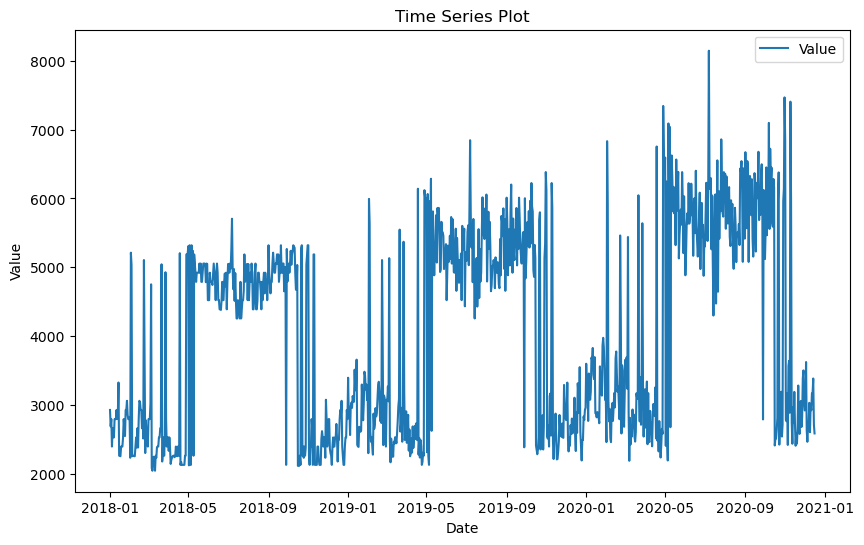

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Value'], label='Value')
plt.title('Time Series Plot')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Perform ADF Test

Why Use the ADF Test? <br>
The ADF Test helps you determine whether a time series is stationary by testing the null hypothesis: <br>

Null Hypothesis (H₀): The time series is not stationary (it has a unit root). <br>
Alternative Hypothesis (H₁): The time series is stationary. <br>

p-value: If the p-value is less than 0.05, you reject the null hypothesis, meaning the series is stationary.

# Now that differencing has been applied

In [17]:
result = adfuller(df['Value'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] > 0.05:
    print("The series is not stationary. Differencing will be applied.")
    df['Value_Diff'] = df['Value'].diff().dropna()
    
else:
    print("The series is stationary. Proceeding without differencing.")

ADF Statistic: -2.2124789527936
p-value: 0.20174753235777315
The series is not stationary. Differencing will be applied.


# Stationarity in Forecasting

1. Many time series models (e.g., ARIMA, SARIMA) assume stationarity because their mathematical principles are based on constant mean and variance. <br>
2. Non-stationary series can lead to poor predictions unless stationarity is achieved through transformations.

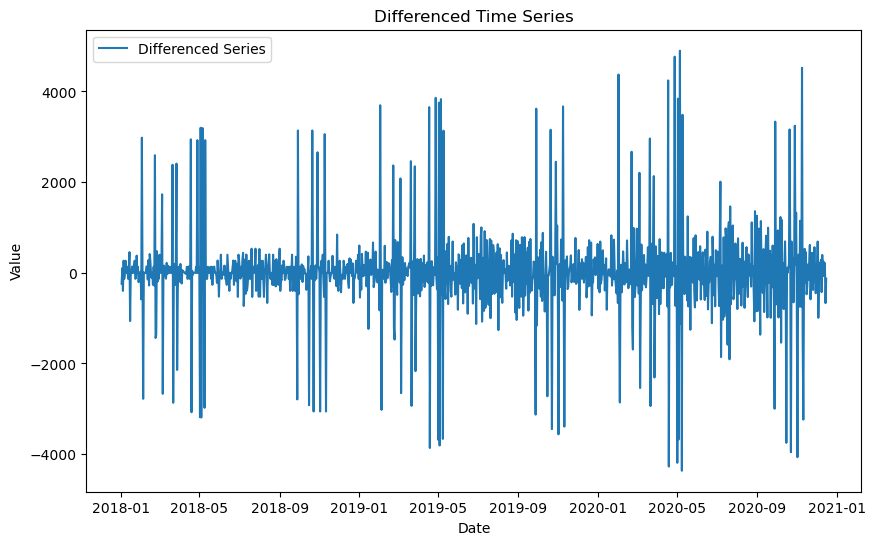

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(df['Value_Diff'], label='Differenced Series')
plt.title('Differenced Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

After `differencing`, the series is transformed to remove trends or seasonality. This makes the series stationary (constant mean and variance). The resulting plot often appears like a random, mean-reverting process with no discernible trends or patterns.

In [19]:
df.head()

,Value,Value_Diff
Formated Date,,
2018-01-01,2926.000,NaN
2018-01-02,2687.531,-238.469
2018-01-03,2793.000,105.469
2018-01-04,2394.000,-399.000
2018-01-05,2660.000,266.000


In [20]:
df = df.drop(df.index[0])  # Drop the first row

# Perform the ADF test again on the differenced series

In [21]:
result_diff = adfuller(df['Value_Diff'])
print("ADF Statistic (Differenced):", result_diff[0])
print("p-value (Differenced):", result_diff[1])

if result_diff[1] > 0.05:
    print("The differenced series is still not stationary.")
else:
    print("The differenced series is stationary. Ready for ARIMA modeling.")


ADF Statistic (Differenced): -9.49854701984996
p-value (Differenced): 3.495239549644816e-16
The differenced series is stationary. Ready for ARIMA modeling.


In [22]:
df.head()

,Value,Value_Diff
Formated Date,,
2018-01-02,2687.531,-238.469
2018-01-03,2793.000,105.469
2018-01-04,2394.000,-399.000
2018-01-05,2660.000,266.000
2018-01-06,2527.000,-133.000


In [23]:
df = df.drop(['Value_Diff'], axis=1)
df.head()

,Value
Formated Date,
2018-01-02,2687.531
2018-01-03,2793.000
2018-01-04,2394.000
2018-01-05,2660.000
2018-01-06,2527.000


# Define ARIMA parameters (p, d, q)

In [24]:
df = df.asfreq('D')  # Assign a daily frequency
print(df.index.freq)  # Should show 'D' for daily data, also alailable, H, W, Y

<Day>


In [25]:
# Specifies the ARIMA model configuration.
p, d, q = 2, 1, 2 # p -> AutoRegressive Order, d-> Differencing Order, q-> Moving Average Order

# Fit the ARIMA model
arima_model = ARIMA(df['Value'], order=(p, d, q))  # Use the original 'Value' column
arima_fitted = arima_model.fit()

`Step 1:` First-order differencing (d=1) is applied to the series to remove trends and make it stationary. <br>
`Step 2:` The AR (AutoRegressive) part (p=2) fits a model using the last 2 lagged values of the differenced series. <br>
`Step 3:` The MA (Moving Average) part (q=2) incorporates the last 2 error terms from previous predictions.

The past lags (p) and error terms (q) will continue to `influence future values` in the same way as they did during the training period.

In [26]:
# Print the model summary
print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                 1080
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8796.609
Date:                Sat, 14 Dec 2024   AIC                          17603.218
Time:                        15:41:50   BIC                          17628.137
Sample:                    01-02-2018   HQIC                         17612.654
                         - 12-16-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4786      0.145     -3.298      0.001      -0.763      -0.194
ar.L2          0.1836      0.056      3.290      0.001       0.074       0.293
ma.L1         -0.0926      0.145     -0.638      0.5

`Log Likelihood:` -8796.609 <br>
Higher (less negative) values indicate a better fit. <br>
`AIC (Akaike Information Criterion):` 17603.218 <br>
Lower AIC values are better, as they penalize complexity and reward goodness-of-fit. <br>
`BIC (Bayesian Information Criterion):` 17628.137 <br>
Similar to AIC but penalizes complexity more strongly. <br>
`HQIC (Hannan-Quinn Information Criterion):` 17612.654 <br>
Another model selection criterion, balancing fit and complexity. <br>

In [28]:
# Forecast future values
forecast_steps = 20  # Number of steps to forecast
forecast = arima_fitted.forecast(steps=forecast_steps)
print("ARIMA Forecast:\n",forecast)

ARIMA Forecast:
 2020-12-17    2844.786751
2020-12-18    2885.430748
2020-12-19    2913.668870
2020-12-20    2907.615850
2020-12-21    2915.697569
2020-12-22    2910.718126
2020-12-23    2914.585227
2020-12-24    2911.820105
2020-12-25    2913.853566
2020-12-26    2912.372621
2020-12-27    2913.454784
2020-12-28    2912.664931
2020-12-29    2913.241660
2020-12-30    2912.820605
2020-12-31    2913.128021
2021-01-01    2912.903578
2021-01-02    2913.067444
2021-01-03    2912.947806
2021-01-04    2913.035153
2021-01-05    2912.971381
Freq: D, Name: predicted_mean, dtype: float64


In [29]:
df_fb.tail()

,Value,Formated Date
1075,3167.594500,2020-12-12
1076,3167.594500,2020-12-13
1077,3383.354511,2020-12-14
1078,2714.591329,2020-12-15
1079,2585.035107,2020-12-16


# Prophet Model

[Read - Facebook GitHub](https://facebook.github.io/prophet/docs/quick_start.html)

In [30]:
df_fb.head()

,Value,Formated Date
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


In [31]:
df_fb.columns = ['y', 'ds']
df_fb.head()

,y,ds
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


In [32]:
m = Prophet(interval_width=0.95, daily_seasonality=True)
model = m.fit(df_fb)

15:52:44 - cmdstanpy - INFO - Chain [1] start processing
15:52:44 - cmdstanpy - INFO - Chain [1] done processing


# 3. Forecast Away

In [36]:
future = m.make_future_dataframe(periods=1000,freq='D')
forecast = m.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-01,3042.708172,805.404287,3944.394639,3042.708172,3042.708172,-636.758612,-636.758612,-636.758612,472.568897,...,16.615617,16.615617,16.615617,-1125.943126,-1125.943126,-1125.943126,0.0,0.0,0.0,2405.949560
1,2018-01-02,3043.440046,874.691647,4031.050882,3043.440046,3043.440046,-646.928879,-646.928879,-646.928879,472.568897,...,-11.291430,-11.291430,-11.291430,-1108.206346,-1108.206346,-1108.206346,0.0,0.0,0.0,2396.511167
2,2018-01-03,3044.171921,878.698842,3924.059743,3044.171921,3044.171921,-621.144750,-621.144750,-621.144750,472.568897,...,-4.423866,-4.423866,-4.423866,-1089.289781,-1089.289781,-1089.289781,0.0,0.0,0.0,2423.027170
3,2018-01-04,3044.903795,920.404532,4006.508042,3044.903795,3044.903795,-574.201906,-574.201906,-574.201906,472.568897,...,22.497946,22.497946,22.497946,-1069.268749,-1069.268749,-1069.268749,0.0,0.0,0.0,2470.701889
4,2018-01-05,3045.635670,874.575746,4097.102262,3045.635670,3045.635670,-610.268414,-610.268414,-610.268414,472.568897,...,-34.566066,-34.566066,-34.566066,-1048.271245,-1048.271245,-1048.271245,0.0,0.0,0.0,2435.367255


In [37]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2075,2023-09-08,5215.642362,5326.111830,8522.798782,5100.003271,5329.900248,1689.382633,1689.382633,1689.382633,472.568897,...,-34.566066,-34.566066,-34.566066,1251.379802,1251.379802,1251.379802,0.0,0.0,0.0,6905.024995
2076,2023-09-09,5216.728739,5461.816329,8405.770470,5100.931436,5331.205454,1712.529558,1712.529558,1712.529558,472.568897,...,-14.019298,-14.019298,-14.019298,1253.979959,1253.979959,1253.979959,0.0,0.0,0.0,6929.258297
2077,2023-09-10,5217.815116,5373.377629,8529.647622,5101.859601,5332.510359,1755.953166,1755.953166,1755.953166,472.568897,...,25.187096,25.187096,25.187096,1258.197174,1258.197174,1258.197174,0.0,0.0,0.0,6973.768282
2078,2023-09-11,5218.901493,5419.953744,8712.922188,5102.787766,5333.815265,1753.337153,1753.337153,1753.337153,472.568897,...,16.615617,16.615617,16.615617,1264.152639,1264.152639,1264.152639,0.0,0.0,0.0,6972.238646
2079,2023-09-12,5219.987870,5389.548146,8657.805971,5103.715931,5335.120170,1733.168027,1733.168027,1733.168027,472.568897,...,-11.291430,-11.291430,-11.291430,1271.890560,1271.890560,1271.890560,0.0,0.0,0.0,6953.155896


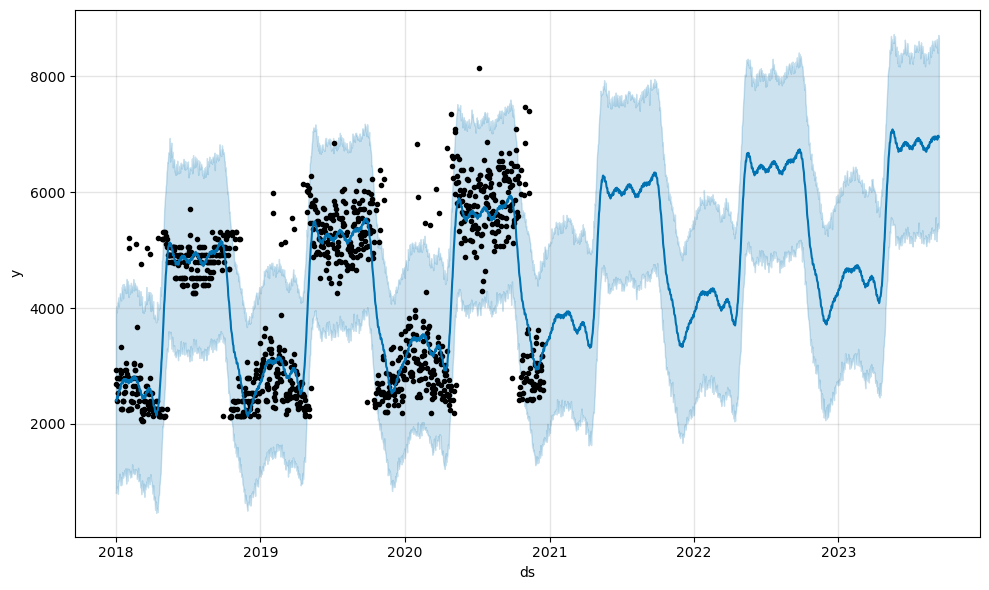

In [38]:
plot1 = m.plot(forecast)

# Top Freelancing Sites in Europe for Machine Learning

1. **Upwork**  
2. **Freelancer.de**  
3. **Toptal**  
4. **Freelancermap**  
5. **Twago**  
6. **Xing**
```